<a href="https://colab.research.google.com/github/th900/Ciencia-de-dados-para-o-agronegocio/blob/main/Ci%C3%AAncia_de_dados_para_agronegocio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
!pip install catboost

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import warnings
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix,classification_report

warnings.filterwarnings("ignore")

In [34]:
RAW_PATH = "https://raw.githubusercontent.com/th900/Ciencia-de-dados-para-o-agronegocio/refs/heads/main/treino.csv"

df = pd.read_csv(RAW_PATH)
print("=" * 60)
print("1. DATASET CARREGADO")
print(f"   Shape: {df.shape}")
print("=" * 60)

1. DATASET CARREGADO
   Shape: (88858, 10)


In [35]:
df.head(10)

,ID,Estimated_Insects_Count,Crop_Type,Soil_Type,Pesticide_Use_Category,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Season,Crop_Damage
0,F00000001,188,1,0,1,0,0.0,0,1,0
1,F00000003,209,1,0,1,0,0.0,0,2,1
2,F00000004,257,1,0,1,0,0.0,0,2,1
3,F00000005,257,1,1,1,0,0.0,0,2,1
4,F00000006,342,1,0,1,0,0.0,0,2,1
5,F00000008,448,0,1,1,0,NaN,0,2,1
6,F00000009,448,0,1,1,0,NaN,0,2,1
7,F00000010,577,1,0,1,0,0.0,0,1,2
8,F00000012,731,0,0,1,0,0.0,0,2,0
9,F00000020,1132,1,0,1,0,0.0,0,1,2


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88858 entries, 0 to 88857
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ID                       88858 non-null  object 
 1   Estimated_Insects_Count  88858 non-null  int64  
 2   Crop_Type                88858 non-null  int64  
 3   Soil_Type                88858 non-null  int64  
 4   Pesticide_Use_Category   88858 non-null  int64  
 5   Number_Doses_Week        88858 non-null  int64  
 6   Number_Weeks_Used        79858 non-null  float64
 7   Number_Weeks_Quit        88858 non-null  int64  
 8   Season                   88858 non-null  int64  
 9   Crop_Damage              88858 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 6.8+ MB


In [37]:
df["Crop_Damage"].value_counts()

,count
Crop_Damage,
0,74238
1,12307
2,2313


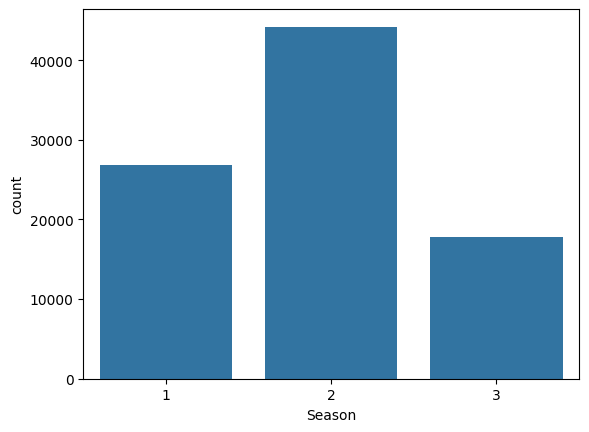

In [38]:
df['Season'].value_counts()
ax = sns.countplot(x=df['Season'])

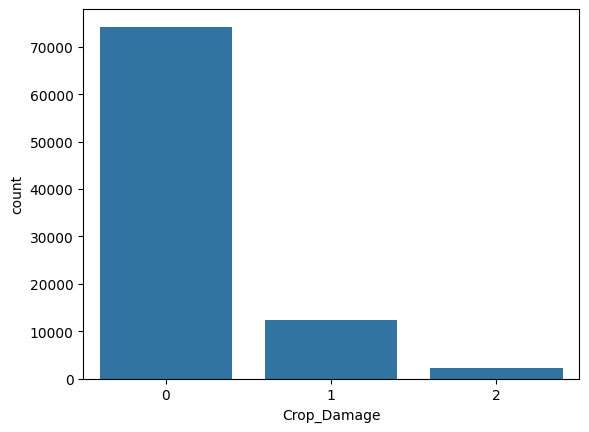

In [39]:
df['Crop_Damage'].value_counts()
ax = sns.countplot(x = df['Crop_Damage'])

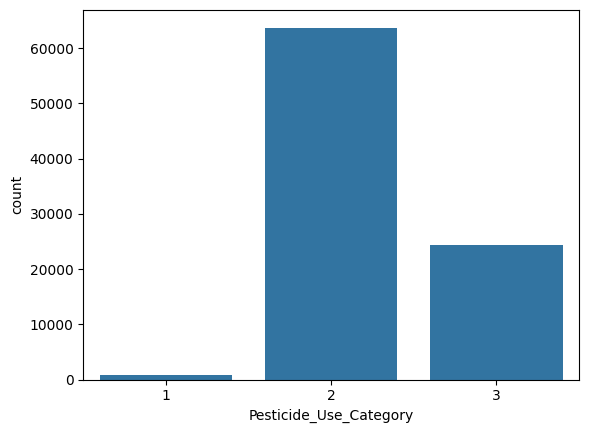

In [40]:
df['Pesticide_Use_Category'].value_counts()
ax = sns.countplot(x = df['Pesticide_Use_Category'])

In [41]:
df.isnull().sum()

,0
ID,0
Estimated_Insects_Count,0
Crop_Type,0
Soil_Type,0
Pesticide_Use_Category,0
Number_Doses_Week,0
Number_Weeks_Used,9000
Number_Weeks_Quit,0
Season,0
Crop_Damage,0


In [42]:
df.duplicated().sum()

np.int64(0)

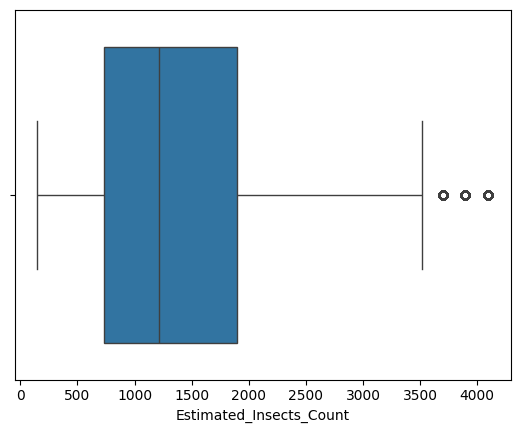

In [43]:
df['Estimated_Insects_Count'].describe()
ax= sns.boxplot( x = df['Estimated_Insects_Count'])

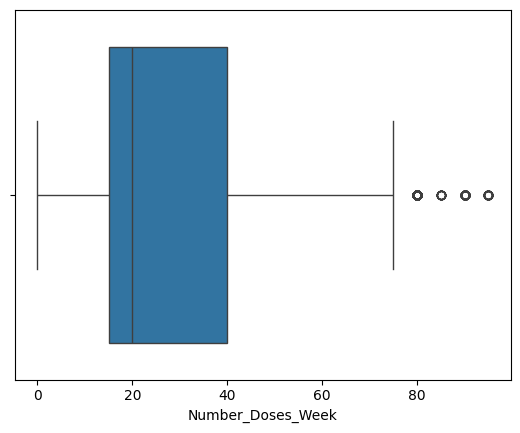

In [44]:
df['Number_Doses_Week'].describe()
ax = sns.boxplot(x = df['Number_Doses_Week'])

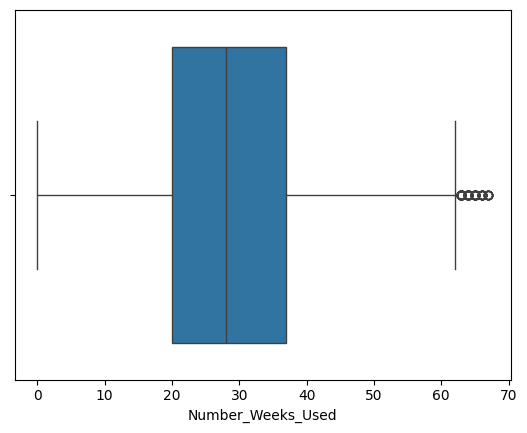

In [45]:
df['Number_Weeks_Used'].describe()
ax = sns.boxplot(x = df['Number_Weeks_Used'])

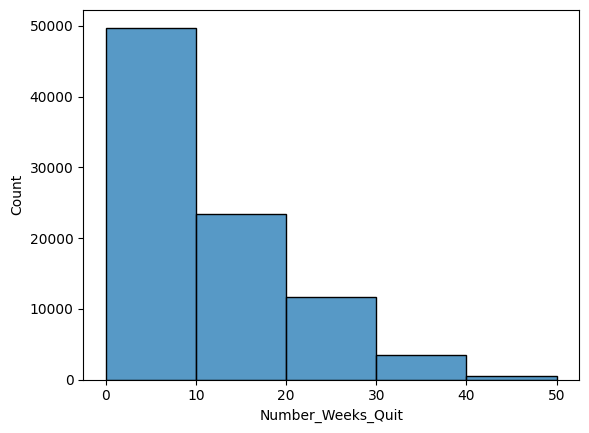

In [46]:
df['Number_Weeks_Quit'].describe()
ax = sns.histplot(x = df['Number_Weeks_Quit'], bins = 5)

In [47]:
# Cria flag antes de imputar
df['weeks_used_missing'] = df['Number_Weeks_Used'].isna().astype(int)
df['Number_Weeks_Used'] = df['Number_Weeks_Used'].fillna(0)
# Não perde nenhuma linha!

In [48]:
df.drop(columns=["ID"], axis = 1, inplace=True)

In [49]:
df.head(4)

,Estimated_Insects_Count,Crop_Type,Soil_Type,Pesticide_Use_Category,Number_Doses_Week,Number_Weeks_Used,Number_Weeks_Quit,Season,Crop_Damage,weeks_used_missing
0,188,1,0,1,0,0.0,0,1,0,0
1,209,1,0,1,0,0.0,0,2,1,0
2,257,1,0,1,0,0.0,0,2,1,0
3,257,1,1,1,0,0.0,0,2,1,0


In [50]:
X = df.drop(['Crop_Damage'], axis = 1)
y = df['Crop_Damage']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

In [51]:
cat_features = ['Crop_Type', 'Soil_Type', 'Pesticide_Use_Category', 'Season']
model = CatBoostClassifier(random_state=42, task_type="GPU", cat_features=cat_features)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



Learning rate set to 0.154899
0:	learn: 0.9203938	total: 111ms	remaining: 1m 51s
1:	learn: 0.8044357	total: 195ms	remaining: 1m 37s
2:	learn: 0.7226121	total: 254ms	remaining: 1m 24s
3:	learn: 0.6619600	total: 325ms	remaining: 1m 20s
4:	learn: 0.6161970	total: 399ms	remaining: 1m 19s
5:	learn: 0.5805921	total: 582ms	remaining: 1m 36s
6:	learn: 0.5526651	total: 760ms	remaining: 1m 47s
7:	learn: 0.5303128	total: 930ms	remaining: 1m 55s
8:	learn: 0.5123184	total: 1.16s	remaining: 2m 7s
9:	learn: 0.4978857	total: 1.35s	remaining: 2m 14s
10:	learn: 0.4862020	total: 1.6s	remaining: 2m 23s
11:	learn: 0.4763325	total: 1.71s	remaining: 2m 21s
12:	learn: 0.4685362	total: 1.79s	remaining: 2m 16s
13:	learn: 0.4619923	total: 1.86s	remaining: 2m 10s
14:	learn: 0.4567372	total: 1.9s	remaining: 2m 5s
15:	learn: 0.4527942	total: 1.96s	remaining: 2m
16:	learn: 0.4491424	total: 2.01s	remaining: 1m 56s
17:	learn: 0.4450810	total: 2.06s	remaining: 1m 52s
18:	learn: 0.4418149	total: 2.15s	remaining: 1m 51s


In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92     14848
           1       0.50      0.19      0.28      2461
           2       0.05      0.00      0.00       463

    accuracy                           0.84     17772
   macro avg       0.47      0.39      0.40     17772
weighted avg       0.79      0.84      0.81     17772



In [67]:
model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=8,
    auto_class_weights='Balanced',   # principal fix para classes raras
    eval_metric='TotalF1',
    early_stopping_rounds=50,
    cat_features=cat_features,
    task_type="GPU",
    random_seed=42,
    verbose=100
)

model.fit(X_train, y_train, eval_set=(X_test, y_test))
y_pred = model.predict(X_test)

0:	learn: 0.5384954	test: 0.5315325	best: 0.5315325 (0)	total: 69.3ms	remaining: 1m 9s
100:	learn: 0.5806252	test: 0.5459747	best: 0.5478473 (75)	total: 1.73s	remaining: 15.4s
200:	learn: 0.6142174	test: 0.5484222	best: 0.5500851 (173)	total: 3.28s	remaining: 13s
bestTest = 0.5500850672
bestIteration = 173
Shrink model to first 174 iterations.


In [68]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.71      0.81     14848
           1       0.24      0.35      0.29      2461
           2       0.10      0.62      0.17       463

    accuracy                           0.66     17772
   macro avg       0.42      0.56      0.42     17772
weighted avg       0.82      0.66      0.72     17772

